<a href="https://colab.research.google.com/github/baubyte/CienciaDeDatos/blob/main/Semana_7/pildoras_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis Exploratorio de Datos (EDA)
### Dataset: Encuesta de hogares Argentina — ingresos, gastos y condiciones socioeconómicas

> **¿Qué es el EDA?**
> El Análisis Exploratorio de Datos es el proceso de *explorar y comprender* un dataset antes de aplicar modelos o sacar conclusiones. El objetivo no es responder preguntas definitivas sino formular las preguntas correctas. Como decía John Tukey, su pionero: *"el análisis exploratorio puede sugerir lo que debes preguntar, no solo responder lo que ya sabes"*.
>
> El EDA combina **estadísticas descriptivas** (números que resumen los datos) con **visualizaciones** (gráficos que revelan patrones). Ambas herramientas se complementan — un número sin gráfico puede ocultar información, y un gráfico sin números puede engañar.

---

##  Etapa 1 — Comprensión inicial del dataset

> Antes de cualquier análisis, el primer paso es entender qué tiene el dataset: cuántas filas y columnas, qué tipo de dato es cada variable, y si hay valores faltantes. Esta etapa orienta todo lo que sigue.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

In [2]:
df = pd.read_csv('hogares_argentina.csv')
print(f'Filas: {df.shape[0]} | Columnas: {df.shape[1]}')
df.head()

Filas: 800 | Columnas: 12


,region,nivel_educativo,tipo_empleo,tipo_vivienda,miembros_hogar,ingreso_mensual,gasto_alimentos,gasto_vivienda,gasto_salud,gasto_educacion,ahorro_mensual,acceso_servicios
0,Pampeana,Terciario,Informal,Casa propia,2,206578,64267,48508,2057,7183.0,80011.0,4.5
1,AMBA,Primario,Formal,Casa propia,4,387882,161228,103773,30527,871.0,79473.0,1.1
2,AMBA,Secundario,Informal,Casa propia,2,154754,59114,62921,5487,13709.0,7046.0,3.2
3,Patagonia,Terciario,Formal,Casa propia,3,382296,122628,83032,18048,23257.0,118640.0,1.9
4,NEA,Secundario,Informal,Alquilada,3,132911,39275,15684,6392,17101.0,NaN,1.9


In [3]:
# Revisión inicial: tipos de datos y valores faltantes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   region            800 non-null    object 
 1   nivel_educativo   800 non-null    object 
 2   tipo_empleo       800 non-null    object 
 3   tipo_vivienda     800 non-null    object 
 4   miembros_hogar    800 non-null    int64  
 5   ingreso_mensual   800 non-null    int64  
 6   gasto_alimentos   800 non-null    int64  
 7   gasto_vivienda    800 non-null    int64  
 8   gasto_salud       800 non-null    int64  
 9   gasto_educacion   680 non-null    float64
 10  ahorro_mensual    720 non-null    float64
 11  acceso_servicios  800 non-null    float64
dtypes: float64(3), int64(5), object(4)
memory usage: 75.1+ KB


In [4]:
# Porcentaje de valores faltantes por columna
faltantes = (df.isnull().sum() / len(df) * 100).round(1)
print('Porcentaje de valores faltantes:')
print(faltantes[faltantes > 0])

Porcentaje de valores faltantes:
gasto_educacion    15.0
ahorro_mensual     10.0
dtype: float64



---

## 1. Medidas de tendencia central y dispersión

> **Síntesis teórica**
>
> **Medidas de tendencia central** — indican dónde se concentran los datos:
> - **Media** *(mean)*: promedio aritmético. Sensible a valores extremos.
> - **Mediana** *(median)*: valor que divide los datos en dos mitades iguales. Más robusta ante outliers.
> - **Moda** *(mode)*: valor más frecuente. Se usa principalmente en variables categóricas.
>
> **Medidas de dispersión** — indican cuánto se alejan los datos de la tendencia central:
> - **Desvío estándar** *(std)*: promedio de las distancias al valor medio.
> - **Rango intercuartil (IQR)**: distancia entre Q1 y Q3. Mide la dispersión del 50% central ignorando los extremos.
>
> **¿Cuándo usar media y cuándo mediana?** Si la distribución es simétrica, ambas coinciden. Si hay outliers o sesgo, la mediana es más representativa del caso típico.

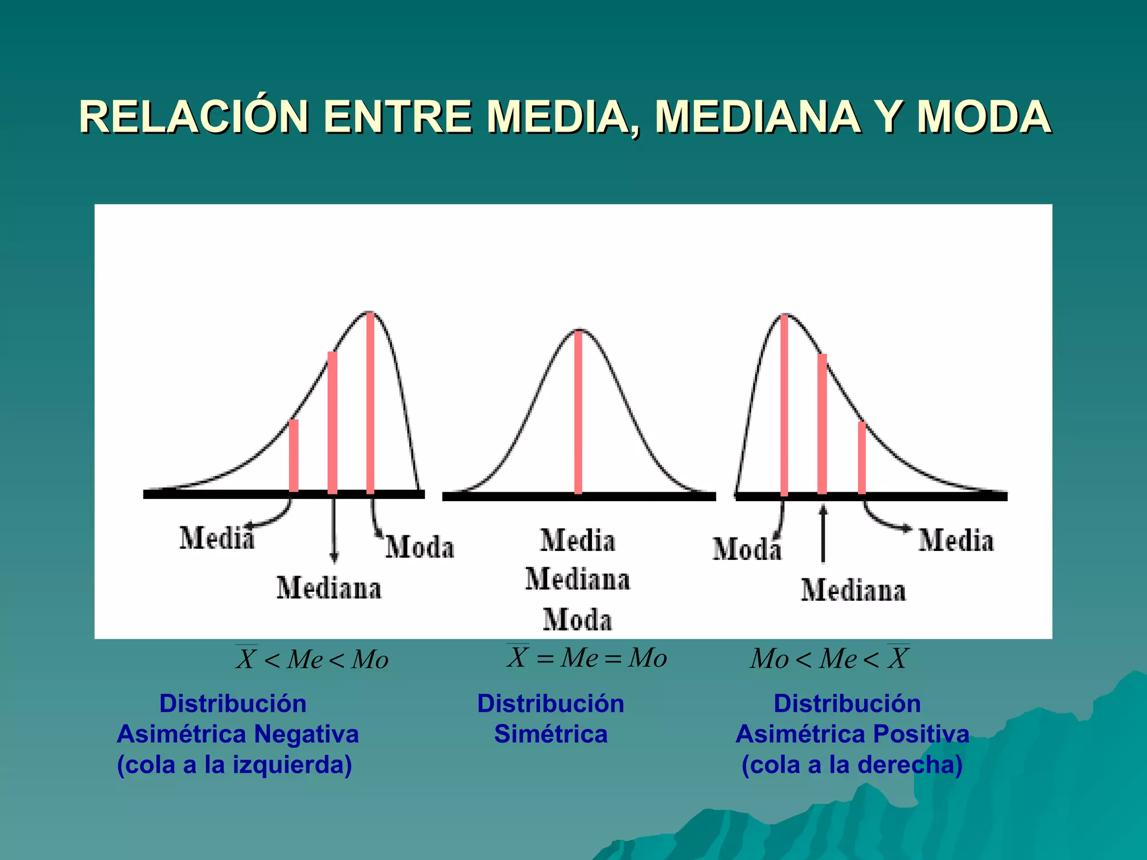

In [5]:
# .describe() calcula las medidas principales para todas las variables numéricas
df.describe().round(0)

,miembros_hogar,ingreso_mensual,gasto_alimentos,gasto_vivienda,gasto_salud,gasto_educacion,ahorro_mensual,acceso_servicios
count,800.0,800.0,800.0,800.0,800.0,680.0,720.0,800.0
mean,3.0,262319.0,91734.0,64695.0,19850.0,12984.0,71360.0,2.0
std,2.0,308073.0,111845.0,77575.0,26633.0,17059.0,93758.0,2.0
min,1.0,18811.0,15000.0,0.0,0.0,0.0,-29166.0,0.0
25%,2.0,115150.0,39062.0,26381.0,7340.0,3980.0,26050.0,1.0
50%,3.0,199053.0,66333.0,46120.0,14130.0,8748.0,53165.0,2.0
75%,4.0,311912.0,110688.0,78450.0,24503.0,17138.0,89601.0,4.0
max,7.0,4769881.0,1707108.0,949137.0,448286.0,250630.0,1604666.0,10.0


---

## Etapa 2 — Exploración de variables individuales

> Analizamos cada variable por separado: su distribución, su tendencia central, su dispersión y si tiene outliers. Esta etapa es la base del EDA — no se puede explorar relaciones sin entender primero cada variable.

In [6]:
# Comparar media vs. mediana del ingreso
media   = df['ingreso_mensual'].mean()
mediana = df['ingreso_mensual'].median()
desvio  = df['ingreso_mensual'].std()
Q1      = df['ingreso_mensual'].quantile(0.25)
Q3      = df['ingreso_mensual'].quantile(0.75)
IQR     = Q3 - Q1

print(f'Media:    $ {media:,.0f}')
print(f'Mediana:  $ {mediana:,.0f}')
print(f'Dif.:     $ {media - mediana:,.0f}  ← la media supera a la mediana por los outliers altos')
print(f'Std:      $ {desvio:,.0f}')
print(f'Q1:       $ {Q1:,.0f}')
print(f'Q3:       $ {Q3:,.0f}')
print(f'IQR:      $ {IQR:,.0f}')

Media:    $ 262,319
Mediana:  $ 199,053
Dif.:     $ 63,266  ← la media supera a la mediana por los outliers altos
Std:      $ 308,073
Q1:       $ 115,150
Q3:       $ 311,912
IQR:      $ 196,762


> **Para observar:** La media supera a la mediana en más de $60.000. Eso indica distribución con sesgo a la derecha — pocos hogares con ingresos muy altos elevan el promedio. En distribuciones de ingreso la mediana es siempre más informativa.

---
#2.  Distribución Ingreso mensual
## Histograma

> **¿Qué es?** Divide el rango de una variable numérica en intervalos *(bins)* y muestra cuántas observaciones caen en cada uno.
>
> **¿Cuándo usarlo?** Siempre como primer gráfico de cualquier variable numérica. Permite ver la forma de la distribución, dónde se concentran los valores y si hay outliers visibles.
>
> **¿Cómo interpretarlo?**
> - Cola larga a la derecha → sesgo positivo (pocos valores muy altos).
> - Cola larga a la izquierda → sesgo negativo (pocos valores muy bajos).
> - Dos picos → distribución bimodal, posibles dos subgrupos mezclados.
> - Cuando hay sesgo, la media queda del lado de la cola y la mediana se acerca más al centro real.



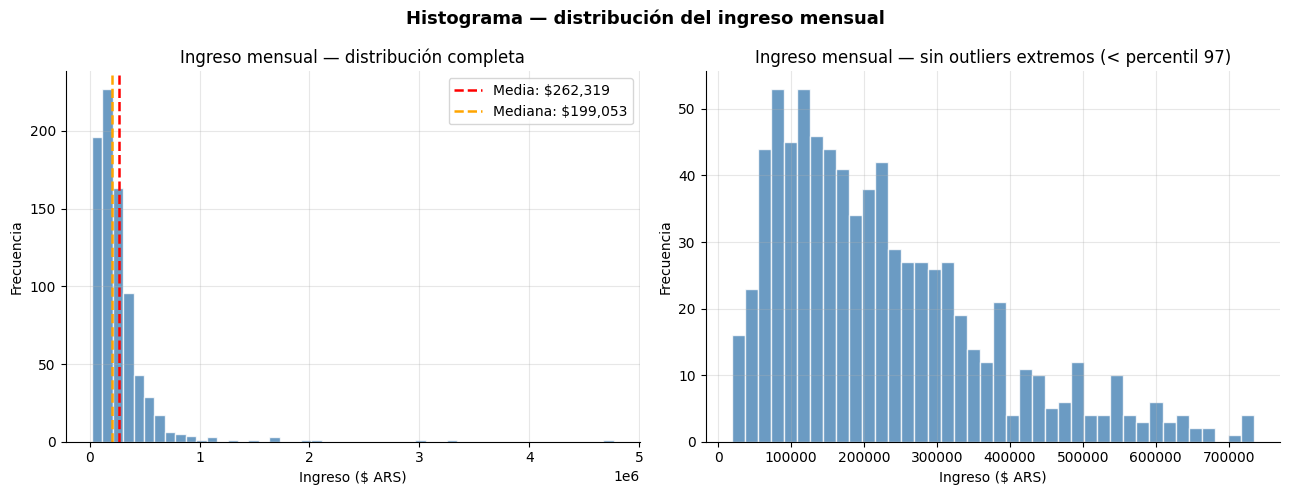

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel izquierdo: distribución completa con media y mediana marcadas
axes[0].hist(df['ingreso_mensual'], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(media,   color='red',    linestyle='--', linewidth=1.8, label=f'Media: ${media:,.0f}')
axes[0].axvline(mediana, color='orange', linestyle='--', linewidth=1.8, label=f'Mediana: ${mediana:,.0f}')
axes[0].set_title('Ingreso mensual — distribución completa')
axes[0].set_xlabel('Ingreso ($ ARS)')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

# Panel derecho: sin outliers extremos (percentil 97)
# Permite ver mejor dónde se concentra el 97% de los hogares
p97 = df['ingreso_mensual'].quantile(0.97)
axes[1].hist(df[df['ingreso_mensual'] < p97]['ingreso_mensual'],
             bins=40, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].set_title('Ingreso mensual — sin outliers extremos (< percentil 97)')
axes[1].set_xlabel('Ingreso ($ ARS)')
axes[1].set_ylabel('Frecuencia')

plt.suptitle('Histograma — distribución del ingreso mensual', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

> **Interpretación:** El panel izquierdo muestra el sesgo positivo: la cola larga hacia la derecha aplasta el resto de la distribución y aleja la media de la mediana. El panel derecho, sin los valores extremos, muestra cómo se distribuye el hogar típico — la mayoría entre $100.000 y $400.000 mensuales.

---
# 3. Distribución del ingreso mensual por tipo de empleo
## Boxplot — diagrama de caja y bigotes

> **¿Qué es?** Representa en un solo gráfico la mediana, los cuartiles, los bigotes y los outliers. Es la herramienta más compacta para comparar distribuciones entre grupos.
>
> **Componentes:**
> - **Caja**: de Q1 a Q3. Contiene el 50% central de los datos. Su altura es el IQR.
> - **Línea interior**: mediana.
> - **Bigotes**: hasta 1.5 × IQR desde cada extremo de la caja.
> - **Puntos** fuera de los bigotes: outliers.
>
> **¿Cuándo usarlo?** Para comparar la distribución de una variable numérica entre grupos categóricos.
>
> **¿Cómo interpretarlo?**
> - Caja alta → alta variabilidad dentro del grupo.
> - Mediana desplazada hacia un extremo de la caja → distribución asimétrica.
> - Bigotes de distinto largo → asimetría en los extremos.
> - Muchos puntos → distribución con colas pesadas.

> **¿Por qué el boxplot después del histograma?**
> El histograma muestra la forma general de la distribución de una variable. El boxplot la complementa con precisión: extrae y hace visibles las cinco medidas clave (mínimo, Q1, mediana, Q3, máximo) y marca los outliers de forma explícita. Su verdadero potencial aparece cuando se usa para **comparar grupos** — en un solo gráfico se puede ver si dos o más categorías tienen distribuciones distintas, sin necesidad de hacer un histograma por grupo. En esta sección lo usamos para comparar el ingreso según el tipo de empleo.

/tmp/ipykernel_6047/272378530.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(grupos, labels=orden_empleo, patch_artist=True,


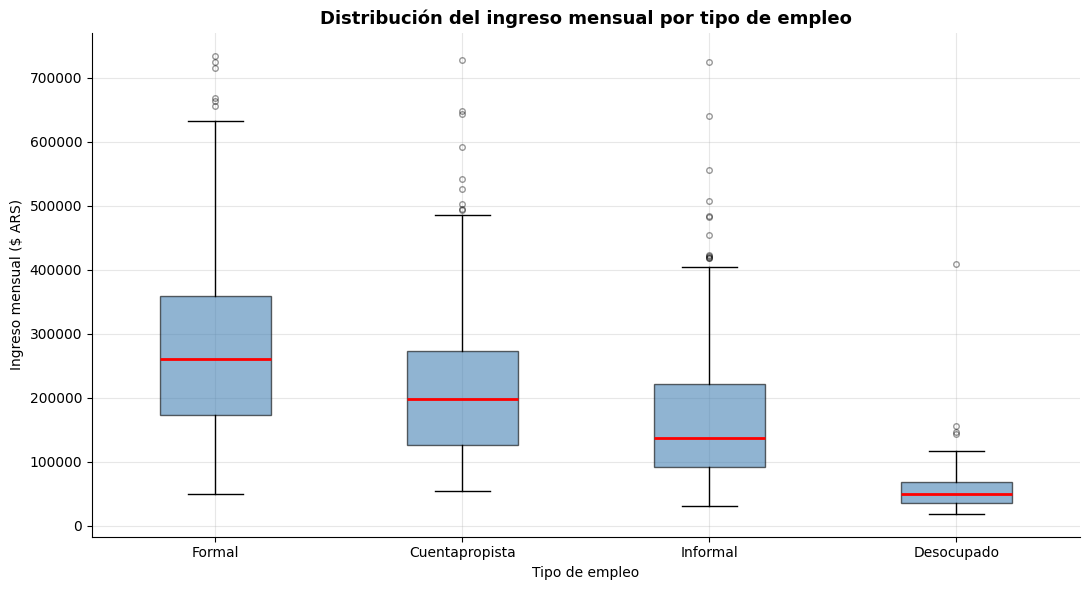

In [8]:
# Filtrar outliers extremos para mejor visualización
df_viz = df[df['ingreso_mensual'] < df['ingreso_mensual'].quantile(0.97)].copy()

# Ordenar categorías por mediana de ingreso
orden_empleo = (df_viz.groupby('tipo_empleo')['ingreso_mensual']
                .median().sort_values(ascending=False).index.tolist())

# Agrupar datos por categoría
grupos = [df_viz[df_viz['tipo_empleo'] == cat]['ingreso_mensual'].dropna()
          for cat in orden_empleo]

fig, ax = plt.subplots(figsize=(11, 6))

# patch_artist=True: rellena las cajas con color
# medianprops: estilo de la línea de mediana
# flierprops: estilo de los puntos outliers
bp = ax.boxplot(grupos, labels=orden_empleo, patch_artist=True,
                medianprops=dict(color='red', linewidth=2),
                boxprops=dict(facecolor='steelblue', alpha=0.6),
                flierprops=dict(marker='o', markersize=4, alpha=0.4, color='steelblue'))

ax.set_title('Distribución del ingreso mensual por tipo de empleo', fontsize=13, fontweight='bold')
ax.set_xlabel('Tipo de empleo')
ax.set_ylabel('Ingreso mensual ($ ARS)')
plt.tight_layout()
plt.show()

> **Interpretación:**
> - **Formal**: mediana más alta y caja más compacta — mayor ingreso y menor dispersión.
> - **Informal**: caja más alta — mayor variabilidad en los ingresos informales.
> - **Desocupados**: mediana más baja con varios outliers por encima — algunos tienen ingresos eventuales adicionales.
> - La línea roja es la mediana. Comparar esas líneas entre grupos es la lectura principal del boxplot comparativo.

---

# 4. Distribución nivel educativo y distribución por región

## Gráfico de barras y gráfico de torta

> **¿Qué son?** Ambos representan la **distribución de variables categóricas**.
>
> El **gráfico de barras** asigna una barra proporcional a la frecuencia de cada categoría. Permite comparaciones precisas entre categorías.
>
> El **gráfico de torta** representa cada categoría como una porción de un círculo que suma el 100%.
>
> **¿Cuándo usar cada uno?**
> - **Barras**: siempre que se quiera comparar frecuencias. Es más preciso y legible.
> - **Torta**: solo con pocas categorías (máximo 5–6) cuando se quiere enfatizar la composición proporcional del total.
> - **Nunca torta** con muchas categorías o proporciones similares — el ojo humano no puede distinguir los sectores con precisión.
>
> **Moda:** en variables categóricas, la categoría más frecuente es la medida de tendencia central equivalente.

> **¿Por qué gráficos de barras y torta?**
> Hasta acá trabajamos solo con variables numéricas. Las variables categóricas no tienen media ni mediana — la medida de tendencia central equivalente es la moda. Para explorarlas necesitamos herramientas distintas. El gráfico de barras y el gráfico de torta son las dos opciones principales para visualizar la distribución de una variable categórica: cuántos casos hay en cada categoría y qué proporción representan sobre el total. En esta sección los usamos para explorar el nivel educativo y la distribución regional de los hogares, y para entender cuándo conviene usar uno u otro.

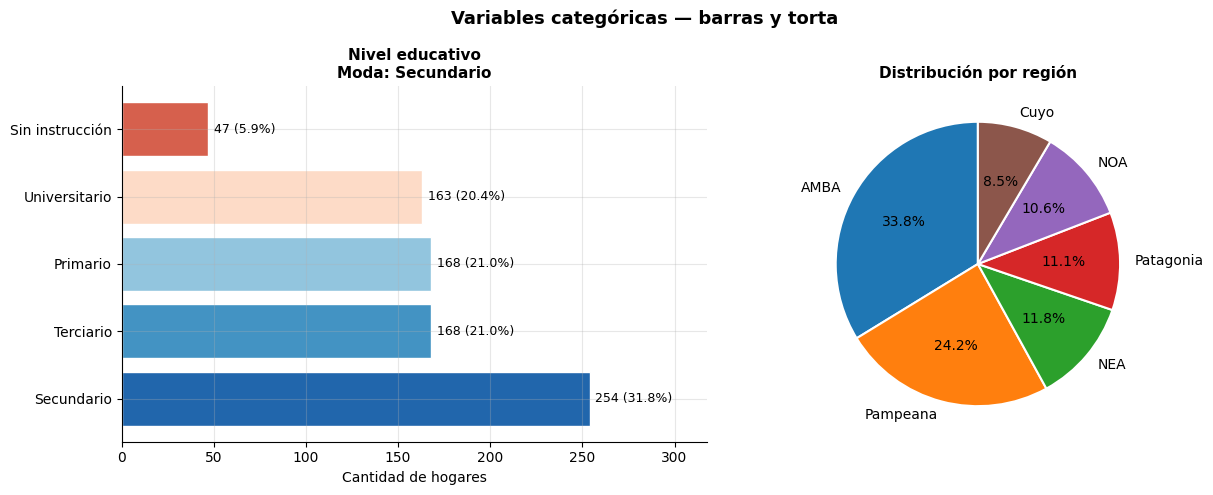

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Gráfico de barras — nivel educativo
conteo_edu = df['nivel_educativo'].value_counts()
colores_edu = ['#2166ac','#4393c3','#92c5de','#fddbc7','#d6604d']

axes[0].barh(conteo_edu.index, conteo_edu.values, color=colores_edu, edgecolor='white')
# Etiquetas al final de cada barra con valor absoluto y porcentaje
for i, v in enumerate(conteo_edu.values):
    axes[0].text(v + 3, i, f'{v} ({v/len(df)*100:.1f}%)', va='center', fontsize=9)
axes[0].set_title(f'Nivel educativo\nModa: {df["nivel_educativo"].mode()[0]}',
                  fontsize=11, fontweight='bold')
axes[0].set_xlabel('Cantidad de hogares')
axes[0].set_xlim(0, conteo_edu.max() * 1.25)

# Gráfico de torta — distribución por región
conteo_reg = df['region'].value_counts()
colores_reg = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd','#8c564b']
axes[1].pie(conteo_reg.values, labels=conteo_reg.index,
            autopct='%1.1f%%', startangle=90,
            colors=colores_reg,
            wedgeprops=dict(edgecolor='white', linewidth=1.5))
axes[1].set_title('Distribución por región', fontsize=11, fontweight='bold')

plt.suptitle('Variables categóricas — barras y torta', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

> **Interpretación:**
> - El nivel más frecuente (moda) es Secundario (~35%). El gráfico de barras permite ver con precisión la diferencia entre cada nivel.
> - La torta de regiones funciona aquí porque hay 6 categorías con diferencias claras. AMBA concentra más del 35% del total. Con más categorías o proporciones similares, el gráfico de barras sería preferible.

---

## 5. Correlación y diagrama de dispersión

> **Síntesis teórica — correlación**
>
> La correlación es una medida estadística que indica el **grado de relación lineal** entre dos variables numéricas.
>
> El **coeficiente de Pearson (r)** varía entre -1 y 1:
> - **r = 1**: correlación positiva perfecta — cuando una sube, la otra sube en proporción constante.
> - **r = 0**: sin relación lineal.
> - **r = -1**: correlación negativa perfecta — cuando una sube, la otra baja.
>
> **Fuerza:** 0.0–0.1 sin correlación · 0.1–0.3 débil · 0.3–0.5 moderada · 0.5–0.7 alta · 0.7–1.0 muy alta.
>
> ⚠️ **Correlación no implica causalidad.** Que dos variables estén correlacionadas no significa que una cause a la otra.
>
> **¿Qué es el diagrama de dispersión?** Muestra la relación entre dos variables numéricas representando cada observación como un punto. Permite ver si la relación existe, en qué dirección va, qué tan fuerte es y si es lineal o tiene otra forma.

> **¿Por qué correlación y diagrama de dispersión?**
> Las secciones anteriores exploraron cada variable por separado — su distribución, sus medidas descriptivas, su frecuencia. Eso es análisis univariado. A partir de acá pasamos al análisis bivariado: explorar qué pasa cuando ponemos dos variables juntas. La correlación cuantifica la fuerza y dirección de la relación lineal entre dos variables numéricas con un solo número. El diagrama de dispersión la muestra visualmente, punto por punto. Usados juntos permiten responder: ¿estas dos variables se mueven juntas? ¿En qué dirección? ¿Qué tan fuerte es esa relación? En esta sección exploramos las relaciones entre el ingreso y las distintas variables económicas del hogar.

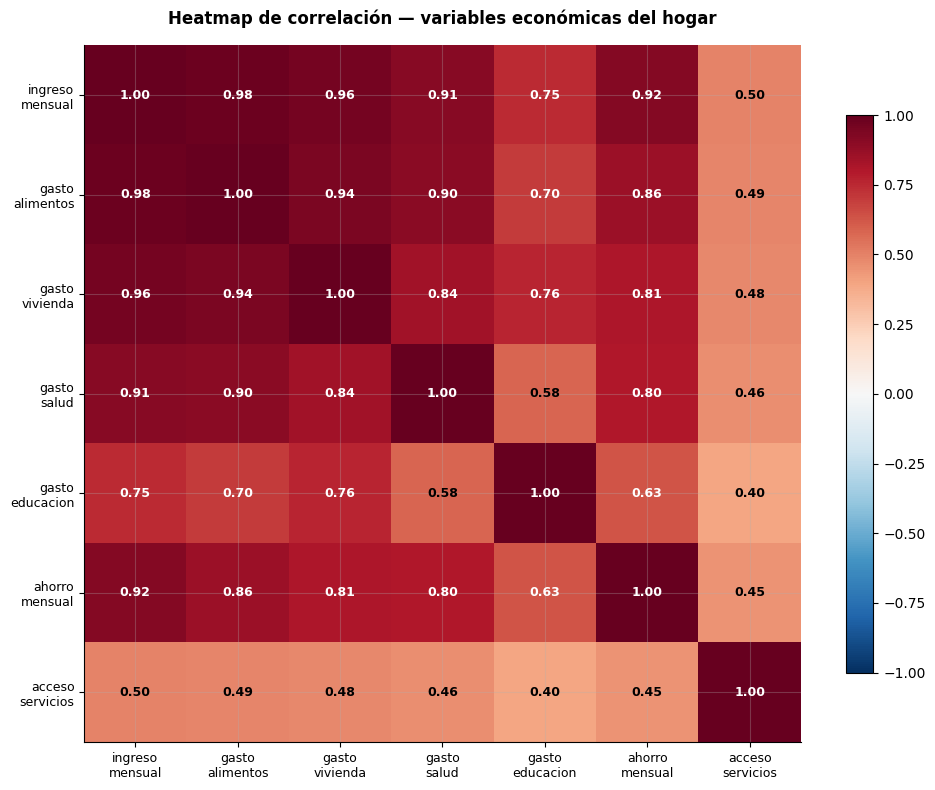

In [10]:
# Matriz de correlación de Pearson
vars_num = ['ingreso_mensual','gasto_alimentos','gasto_vivienda',
            'gasto_salud','gasto_educacion','ahorro_mensual','acceso_servicios']

# .corr() calcula el coeficiente de Pearson entre todos los pares
matriz_corr = df[vars_num].corr()

# Heatmap — mapa de calor de la matriz de correlación
fig, ax = plt.subplots(figsize=(10, 8))

# imshow dibuja la matriz como imagen: cada celda tiene un color
# cmap='RdBu_r': rojo = correlación negativa, azul = positiva
im = ax.imshow(matriz_corr, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')

labels = [v.replace('_', '\n') for v in vars_num]
ax.set_xticks(range(len(vars_num)))
ax.set_yticks(range(len(vars_num)))
ax.set_xticklabels(labels, fontsize=9)
ax.set_yticklabels(labels, fontsize=9)

# Valor numérico dentro de cada celda
for i in range(len(vars_num)):
    for j in range(len(vars_num)):
        val = matriz_corr.iloc[i, j]
        color = 'white' if abs(val) > 0.6 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=9, color=color, fontweight='bold')

plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_title('Heatmap de correlación — variables económicas del hogar',
             fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

---

##  Etapa 3 — Exploración de relaciones entre variables

> Una vez que entendemos cada variable por separado, exploramos cómo se relacionan entre sí. Esta etapa revela patrones que no son visibles al estudiar variables de a una.

> **Interpretación del heatmap:**
> - Azules intensos = correlaciones muy altas positivas. Rojos intensos = correlaciones negativas (no hay en este dataset).
> - El ingreso tiene correlación muy alta (>0.90) con todos los gastos.
> - `acceso_servicios` tiene correlación moderada (~0.6) con el ingreso.
> - La diagonal siempre es 1.0 — cada variable correlaciona perfectamente consigo misma.

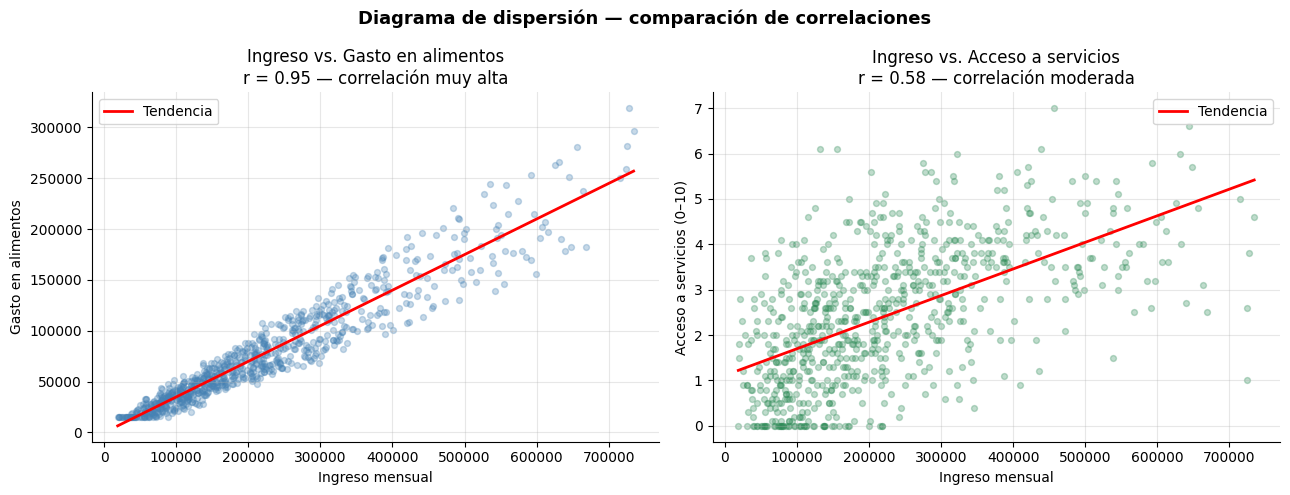

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

x1, y1 = df_viz['ingreso_mensual'], df_viz['gasto_alimentos']
x2, y2 = df_viz['ingreso_mensual'], df_viz['acceso_servicios']

# Panel izquierdo: correlación muy alta
axes[0].scatter(x1, y1, alpha=0.3, color='steelblue', s=18)
z  = np.polyfit(x1, y1, 1)   # ajusta una recta (regresión lineal simple)
x_l = np.linspace(x1.min(), x1.max(), 100)
axes[0].plot(x_l, np.poly1d(z)(x_l), color='red', linewidth=2, label='Tendencia')
r1 = x1.corr(y1)
axes[0].set_title(f'Ingreso vs. Gasto en alimentos\nr = {r1:.2f} — correlación muy alta')
axes[0].set_xlabel('Ingreso mensual')
axes[0].set_ylabel('Gasto en alimentos')
axes[0].legend()

# Panel derecho: correlación moderada
axes[1].scatter(x2, y2, alpha=0.3, color='seagreen', s=18)
z2 = np.polyfit(x2, y2, 1)
axes[1].plot(x_l, np.poly1d(z2)(x_l), color='red', linewidth=2, label='Tendencia')
r2 = x2.corr(y2)
axes[1].set_title(f'Ingreso vs. Acceso a servicios\nr = {r2:.2f} — correlación moderada')
axes[1].set_xlabel('Ingreso mensual')
axes[1].set_ylabel('Acceso a servicios (0–10)')
axes[1].legend()

plt.suptitle('Diagrama de dispersión — comparación de correlaciones', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

> **Interpretación:** La nube más compacta alrededor de la línea roja indica correlación más fuerte. En el panel izquierdo los puntos siguen de cerca la línea (r muy alto). En el panel derecho la nube es más dispersa (r moderado) — el ingreso explica parte del acceso a servicios pero no todo.

---

## 6. Exploración multivariable

> **Síntesis teórica**
>
> Cuando analizamos variables de a una podemos perdernos patrones que solo aparecen en la interacción entre variables. La exploración multivariable permite:
> - Detectar relaciones que no se ven al estudiar variables por separado.
> - Comparar distribuciones entre subgrupos definidos por categorías.
> - Identificar si un valor es outlier en contexto — puede ser normal en un grupo y extremo en otro.
> - Formular hipótesis más ricas y específicas.

### 6a. Boxplot combinado — numérica vs. dos categóricas

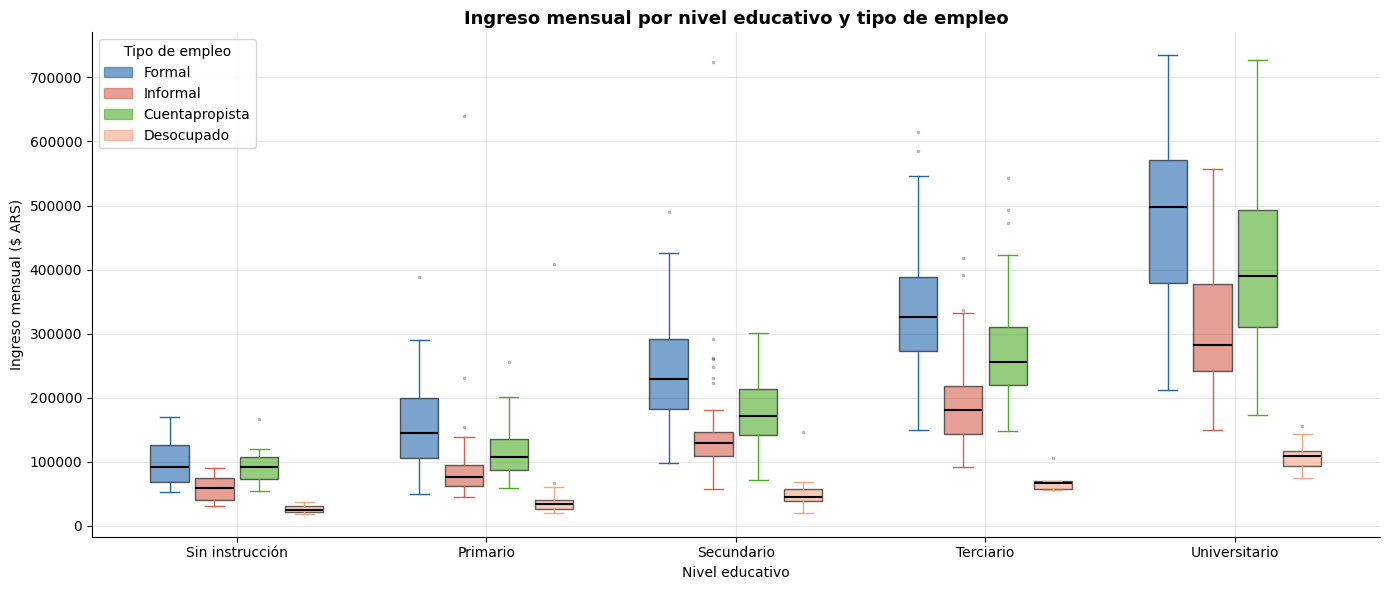

In [12]:
# Ingreso por nivel educativo diferenciando por tipo de empleo
# Muestra la interacción de tres variables en un solo gráfico
orden_edu   = ['Sin instrucción','Primario','Secundario','Terciario','Universitario']
tipos_emp   = ['Formal','Informal','Cuentapropista','Desocupado']
colores_emp = ['#2166ac','#d6604d','#4dac26','#f4a582']

fig, ax = plt.subplots(figsize=(14, 6))
ancho   = 0.18
x_base  = np.arange(len(orden_edu))

for k, (tipo, color) in enumerate(zip(tipos_emp, colores_emp)):
    grupos_edu = [
        df_viz[(df_viz['nivel_educativo'] == edu) &
               (df_viz['tipo_empleo'] == tipo)]['ingreso_mensual'].dropna()
        for edu in orden_edu
    ]
    pos = x_base + (k - 1.5) * ancho
    ax.boxplot(grupos_edu, positions=pos, widths=ancho * 0.85,
               patch_artist=True, manage_ticks=False,
               medianprops=dict(color='black', linewidth=1.5),
               boxprops=dict(facecolor=color, alpha=0.6),
               flierprops=dict(marker='.', markersize=3, alpha=0.3),
               whiskerprops=dict(color=color),
               capprops=dict(color=color))

ax.set_xticks(x_base)
ax.set_xticklabels(orden_edu)
ax.set_title('Ingreso mensual por nivel educativo y tipo de empleo',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Nivel educativo')
ax.set_ylabel('Ingreso mensual ($ ARS)')
parches = [mpatches.Patch(color=c, alpha=0.6, label=t)
           for t, c in zip(tipos_emp, colores_emp)]
ax.legend(handles=parches, title='Tipo de empleo', loc='upper left')
plt.tight_layout()
plt.show()

---

##  Etapa 4 — Exploración multivariable

> Analizamos tres o más variables en conjunto para detectar interacciones y patrones complejos. Muchos fenómenos reales son el resultado de múltiples factores actuando simultáneamente.

> **Interpretación:** El ingreso crece con el nivel educativo en todos los tipos de empleo, pero dentro de cada nivel el tipo de empleo genera diferencias importantes. Un trabajador formal universitario tiene una distribución muy distinta a uno informal con el mismo nivel educativo. Este patrón no sería visible estudiando las variables por separado.

### 6b. Violin plot — distribución completa por grupo

> **¿Qué es?** Combina un boxplot con una estimación de densidad. La forma del violín muestra dónde se concentran los datos — cuanto más ancha la zona, más observaciones tienen ese valor.
>
> **¿Cuándo usarlo?** Cuando la forma de la distribución importa, no solo los cuartiles. Especialmente útil con distribuciones bimodales o irregulares que el boxplot no muestra.
>
> **¿Cómo interpretarlo?** Zona ancha = muchas observaciones. Zona estrecha = pocas observaciones. Violín con panza arriba = sesgo positivo. Violín simétrico = distribución equilibrada.

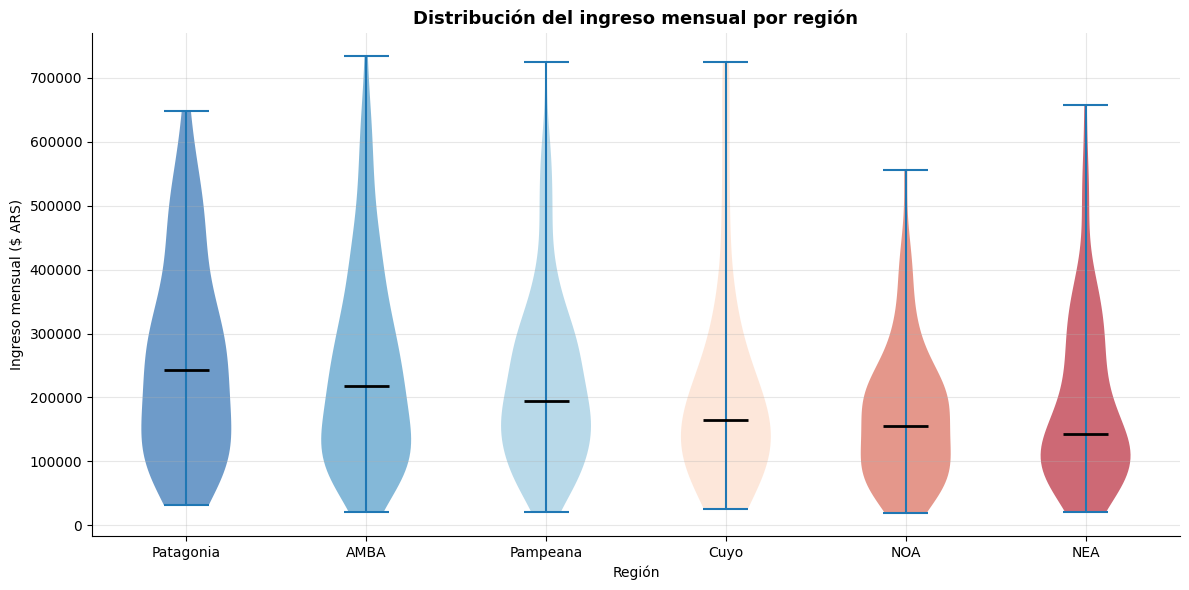

In [13]:
# Violin plot: ingreso por región, ordenado por mediana
orden_reg = (df_viz.groupby('region')['ingreso_mensual']
             .median().sort_values(ascending=False).index.tolist())

grupos_reg = [df_viz[df_viz['region'] == r]['ingreso_mensual'].dropna()
              for r in orden_reg]

fig, ax = plt.subplots(figsize=(12, 6))

# violinplot: showmedians muestra la línea de mediana, showextrema los bigotes
partes = ax.violinplot(grupos_reg, positions=range(len(orden_reg)),
                       showmedians=True, showextrema=True)

colores_v = ['#2166ac','#4393c3','#92c5de','#fddbc7','#d6604d','#b2182b']
for pc, color in zip(partes['bodies'], colores_v):
    pc.set_facecolor(color)
    pc.set_alpha(0.65)
partes['cmedians'].set_color('black')
partes['cmedians'].set_linewidth(2)

ax.set_xticks(range(len(orden_reg)))
ax.set_xticklabels(orden_reg)
ax.set_title('Distribución del ingreso mensual por región',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Región')
ax.set_ylabel('Ingreso mensual ($ ARS)')
plt.tight_layout()
plt.show()

> **Interpretación:** Patagonia tiene un violín más ancho en la parte superior — mayor proporción de hogares con ingresos altos. NOA y NEA tienen violines más estrechos y bajos. AMBA tiene forma intermedia con mayor variabilidad. La forma del violín muestra información que el boxplot no captura: la distribución completa, no solo los cuartiles.

### 6c. Tabla de contingencia — categórica vs. categórica

> **¿Qué es?** Organiza la frecuencia conjunta de dos variables categóricas en una matriz. Cada celda muestra cuántas observaciones combinan una categoría de la variable fila con una de la columna.
>
> **¿Cuándo usarla?** Para explorar si existe asociación entre dos variables categóricas.
>
> **Normalización por fila:** convierte frecuencias absolutas en proporciones, permitiendo comparar grupos de distinto tamaño.
>
> **¿Cómo interpretarla?** Si las proporciones son similares en todas las filas → las variables son independientes. Si varían notablemente → hay una asociación entre ellas.

In [14]:
# Tabla absoluta
# pd.crosstab() cruza dos variables categóricas contando las combinaciones
tabla = pd.crosstab(df['tipo_vivienda'], df['tipo_empleo'],
                    margins=True, margins_name='Total')
print('Tabla de contingencia — frecuencias absolutas:')
print(tabla)

Tabla de contingencia — frecuencias absolutas:
tipo_empleo    Cuentapropista  Desocupado  Formal  Informal  Total
tipo_vivienda                                                     
Alquilada                  41          17     106        63    227
Asentamiento               16           7      38        25     86
Casa propia                73          23     156       118    370
Prestada                   18           3      66        30    117
Total                     148          50     366       236    800


Proporciones por fila:
tipo_empleo    Cuentapropista  Desocupado  Formal  Informal
tipo_vivienda                                              
Alquilada                0.18        0.07    0.47      0.28
Asentamiento             0.19        0.08    0.44      0.29
Casa propia              0.20        0.06    0.42      0.32
Prestada                 0.15        0.03    0.56      0.26


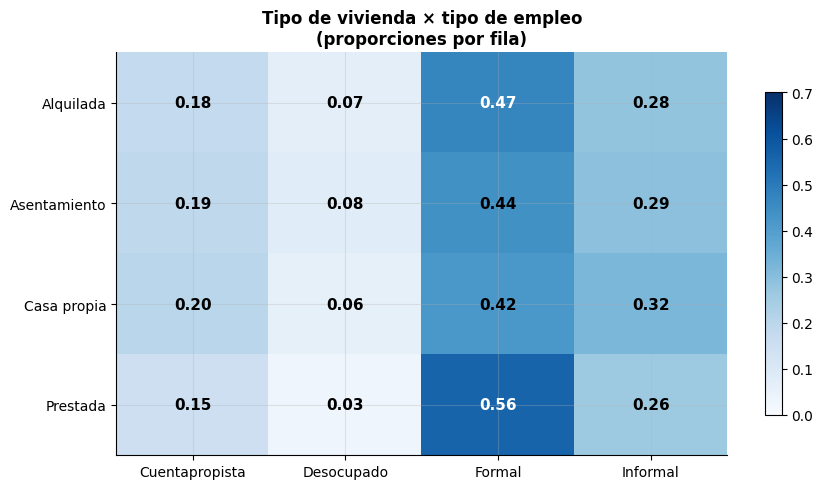

In [15]:
# Tabla normalizada por fila: proporción de cada tipo de empleo
# dentro de cada tipo de vivienda
# normalize='index': divide cada celda por el total de su fila
tabla_norm = pd.crosstab(df['tipo_vivienda'], df['tipo_empleo'],
                          normalize='index').round(2)
print('Proporciones por fila:')
print(tabla_norm)

# Visualización como heatmap
fig, ax = plt.subplots(figsize=(9, 5))
im = ax.imshow(tabla_norm.values, cmap='Blues', vmin=0, vmax=0.7, aspect='auto')

ax.set_xticks(range(len(tabla_norm.columns)))
ax.set_yticks(range(len(tabla_norm.index)))
ax.set_xticklabels(tabla_norm.columns, fontsize=10)
ax.set_yticklabels(tabla_norm.index, fontsize=10)

for i in range(len(tabla_norm.index)):
    for j in range(len(tabla_norm.columns)):
        val = tabla_norm.iloc[i, j]
        color = 'white' if val > 0.45 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=11, color=color, fontweight='bold')

plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_title('Tipo de vivienda × tipo de empleo\n(proporciones por fila)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

> **Interpretación:** Las proporciones varían notablemente entre tipos de vivienda — hay asociación entre las dos variables. Los hogares en asentamientos tienen mayor proporción de empleo informal y desocupación. Los hogares con casa propia concentran mayor proporción de empleo formal. Si todas las filas tuvieran las mismas proporciones, las variables serían independientes.

---

---

##  Etapa 5 — Detección de outliers

> Identificamos valores que se alejan significativamente del patrón general. Esta etapa es fundamental antes de cualquier modelado — los outliers pueden distorsionar los resultados si no se tratan correctamente.

> **Síntesis teórica**
>
> Un outlier *(valor atípico)* es una observación que se aleja significativamente del patrón general. Puede ser:
> - Un **error de carga o medición** → debe corregirse o eliminarse.
> - Un **caso real extremo** → debe analizarse por separado, no eliminarse sin justificación.
>
> **Criterio IQR** — el más común:
> Un valor es outlier si cae fuera del rango `[Q1 − 1.5 × IQR, Q3 + 1.5 × IQR]`.
>
> **¿Qué hacer con los outliers?** Primero entender su origen. Si son errores → corregir. Si son casos reales → decidir si incluirlos, excluirlos o tratarlos por separado. **Nunca eliminar automáticamente sin justificación.**

In [16]:
# Función que detecta outliers por criterio IQR
def detectar_outliers_IQR(serie):
    Q1  = serie.quantile(0.25)
    Q3  = serie.quantile(0.75)
    IQR = Q3 - Q1
    li  = Q1 - 1.5 * IQR   # límite inferior
    ls  = Q3 + 1.5 * IQR   # límite superior
    mask = (serie < li) | (serie > ls)
    return mask.sum(), round(mask.sum() / len(serie) * 100, 1), li, ls

print(f'{"Variable":<25} {"N outliers":>12} {"% total":>10} {"Límite inf":>15} {"Límite sup":>15}')
print('-' * 80)
for var in ['ingreso_mensual','gasto_alimentos','gasto_vivienda','gasto_salud','ahorro_mensual']:
    n, pct, li, ls = detectar_outliers_IQR(df[var].dropna())
    print(f'{var:<25} {n:>12} {pct:>9}% {li:>15,.0f} {ls:>15,.0f}')

Variable                    N outliers    % total      Límite inf      Límite sup
--------------------------------------------------------------------------------
ingreso_mensual                     40       5.0%        -179,992         607,055
gasto_alimentos                     40       5.0%         -68,377         218,126
gasto_vivienda                      47       5.9%         -51,723         156,555
gasto_salud                         42       5.2%         -18,404          50,247
ahorro_mensual                      40       5.6%         -69,277         184,928


> **Interpretación:** El ingreso tiene el mayor porcentaje de outliers — esperable en distribuciones de ingresos asimétricas por naturaleza. El ahorro tiene outliers negativos (hogares endeudados) y positivos (ahorradores intensivos). En este dataset los outliers de ingreso son casos reales, no errores de carga.



## Resumen: ¿qué gráfico usar y cuándo?

| Situación | Gráfico recomendado | Variables |
|---|---|---|
| Distribución de una variable numérica | Histograma | 1 numérica |
| Distribución + outliers | Boxplot | 1 numérica |
| Comparar distribuciones entre grupos | Boxplot combinado / Violin plot | 1 numérica + 1 categórica |
| Distribución de una variable categórica | Gráfico de barras | 1 categórica |
| Composición proporcional (pocas categorías) | Gráfico de torta | 1 categórica |
| Relación entre dos numéricas | Diagrama de dispersión | 2 numéricas |
| Fuerza de relación entre múltiples numéricas | Heatmap de correlación | N numéricas |
| Relación entre dos categóricas | Tabla de contingencia | 2 categóricas |